# General functions for tree analysis

In [1]:
# Tree length, and number of leaves in host and parasite trees
from Bio import Phylo
from io import StringIO
import re
def load_tree(newick_str):

    return Phylo.read(StringIO(newick_str), "newick")

def get_tree_stats(tree):
    num_leaves = len(tree.get_terminals())
    total_branch_length = sum(clade.branch_length for clade in tree.get_nonterminals() + tree.get_terminals() if clade.branch_length)
    max_depth = max(tree.depths().values())
    num_branches = len(tree.get_nonterminals()) + len(tree.get_terminals()) - 1  # Total branches in the tree
    tree_stats = {
        "num_leaves": num_leaves,
        "total_branch_length": total_branch_length,
        "max_depth": max_depth,
        "num_branches": num_branches
    }
    return tree_stats


def average_host_tree_depth(datasets): #num branches
    total_depth = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_depth += dataset['host_tree_stats']['num_branches']
            count += 1
    return total_depth / count if count > 0 else 0


def average_parasite_tree_depth(datasets):#num branches
    total_depth = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_depth += dataset['parasite_tree_stats']['num_branches']
            count += 1
    return total_depth / count if count > 0 else 0



def average_host_tree_length(datasets): # max depth
    total_length = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_length += dataset['host_tree_stats']['max_depth']
            count += 1
    return total_length / count if count > 0 else 0


def average_parasite_tree_length(datasets):# max depth
    total_length = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_length += dataset['parasite_tree_stats']['max_depth']
            count += 1
    return total_length / count if count > 0 else 0


def average_host_tree_leaves(datasets):
    total_leaves = 0
    count = 0
    for dataset in datasets:
        if 'host_tree_stats' in dataset:
            total_leaves += dataset['host_tree_stats']['num_leaves']
            count += 1
    return total_leaves / count if count > 0 else 0

def average_parasite_tree_leaves(datasets):
    total_leaves = 0
    count = 0
    for dataset in datasets:
        if 'parasite_tree_stats' in dataset:
            total_leaves += dataset['parasite_tree_stats']['num_leaves']
            count += 1
    return total_leaves / count if count > 0 else 0

In [2]:
# extract associations and count the number of associations per dataset. Measure the average
def average_associations_per_dataset(datasets):
    total_associations = 0
    count = 0
    for dataset in datasets:
        if 'associations' in dataset:
            total_associations += len(dataset['associations'])
            count += 1
    return total_associations / count if count > 0 else 0

In [105]:
# phylogenetic tree metrics, such as cherry index, Sackin index, and Colless' index
import pandas as pd
from ete3 import Tree
import matplotlib.pyplot as plt
import seaborn as sns

# --- Metric Functions --- #

def count_cherries(tree):
    """Count number of cherries in a tree (pairs of leaves with the same parent)"""
    count = 0
    for node in tree.traverse():
        if not node.is_leaf():
            children = node.get_children()
            if len(children) == 2 and all(child.is_leaf() for child in children):
                count += 1
    return count

def cherry_index(tree):
    cherries = count_cherries(tree)
    leaves = len(tree.get_leaves())
    return cherries / leaves if leaves > 0 else 0

def sackin_index(tree):
    """Sackin index: sum of leaf depths"""
    return sum(tree.get_distance(leaf) for leaf in tree.iter_leaves())

def colless_index(tree):
    """Colless index: sum of imbalance at each internal node (binary trees only)"""
    def imbalance(node):
        if node.is_leaf():
            return 0
        children = node.get_children()
        if len(children) != 2:
            return 0
        left = len(children[0].get_leaves())
        right = len(children[1].get_leaves())
        return abs(left - right) + imbalance(children[0]) + imbalance(children[1])
    return imbalance(tree)

# --- Main Metric Extractor --- #

def compute_tree_metrics(datasets, model_name="Model"):
    results = []
    for ds in datasets:
        host_nwk = ds['host_newick']
        parasite_nwk = ds['parasite_newick']

        # Fix malformed Newick: ensure semicolon at the end
        if not host_nwk.strip().endswith(';'):
            host_nwk += ';'
        if not parasite_nwk.strip().endswith(';'):
            parasite_nwk += ';'

        try:
            h_tree = Tree(host_nwk, format=1)
            p_tree = Tree(parasite_nwk, format=1)
        except Exception as e:
            print(f"[ERROR] Failed to parse trees in file: {ds['filename']} — {e}")
            continue

        results.append({
            'model': model_name,
            'filename': ds['filename'],
            'host_leaves': len(h_tree.get_leaves()),
            'parasite_leaves': len(p_tree.get_leaves()),
            'cherry_index_host': cherry_index(h_tree),
            'cherry_index_parasite': cherry_index(p_tree),
            'sackin_index_host': sackin_index(h_tree),
            'sackin_index_parasite': sackin_index(p_tree),
            'colless_index_host': colless_index(h_tree),
            'colless_index_parasite': colless_index(p_tree),
        })
    return pd.DataFrame(results)



def plot_metric_comparison_paired(df_all, base_metric_name, title=None):
    host_col = f"{base_metric_name}_host"
    parasite_col = f"{base_metric_name}_parasite"

    # Melt the data to long format
    df_melted = df_all.melt(
        id_vars=['model'],
        value_vars=[host_col, parasite_col],
        var_name='metric_type',
        value_name='value'
    )

    # Clean up metric_type for legend (host / parasite)
    df_melted['metric_type'] = df_melted['metric_type'].apply(
        lambda x: 'Host' if 'host' in x else 'Parasite'
    )

    # Plot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_melted, x='model', y='value', hue='metric_type', errorbar='sd')

    plt.title(title or f'{base_metric_name.replace("_", " ").title()} (Host vs Parasite)')
    plt.ylabel(base_metric_name.replace('_', ' ').title())
    plt.xlabel('Model')
    plt.legend(title='Tree Type')
    plt.tight_layout()
    plt.show()


In [124]:
# Parafit value 
import tempfile
import subprocess
import os

def run_parafit_on_dataset(dataset, r_script_path="parafit.R", nperm=999):
    # Unpack the dataset
    host_nwk = dataset['host_newick'].strip() + ";"
    parasite_nwk = dataset['parasite_newick'].strip() + ";"
    associations = dataset['associations']  # List of (parasite, host) pairs

    with tempfile.TemporaryDirectory() as tmpdir:
        # Create temp file paths
        host_path = os.path.join(tmpdir, "host.nwk")
        parasite_path = os.path.join(tmpdir, "parasite.nwk")
        assoc_path = os.path.join(tmpdir, "assoc.txt")

        # Save host and parasite trees
        with open(host_path, "w") as f:
            f.write(host_nwk)
        with open(parasite_path, "w") as f:
            f.write(parasite_nwk)

        # Clean associations: remove trailing commas and whitespace
        with open(assoc_path, "w") as f:
            for p, h in associations:
                p_clean = p.strip().strip(",")
                h_clean = h.strip().strip(",")
                f.write(f"{p_clean}\t{h_clean}\n")

        # Call R script
        cmd = ["Rscript", r_script_path, host_path, parasite_path, assoc_path, str(nperm)]
        try:
            result = subprocess.check_output(cmd, text=True)
            return result
        except subprocess.CalledProcessError as e:
            print(f"[ERROR] R script failed for {dataset['filename']}: {e.output}")
            return None
        
def extract_parafit_values(output_str):
    """Extract stat and p-value from R output."""
    stat_match = re.search(r"ParaFit Global Stat:\s*([\d\.eE+-]+)", output_str)
    pval_match = re.search(r"ParaFit Global P-value:\s*([\d\.eE+-]+)", output_str)

    if stat_match and pval_match:
        return float(stat_match.group(1)), float(pval_match.group(1))
    return None, None

def run_all_parafit(datasets, model_name):
    results = []

    for dataset in datasets:
        print(f"Running ParaFit for {dataset['filename']} ({model_name})")
        output = run_parafit_on_dataset(dataset)

        if output:
            stat, pval = extract_parafit_values(output)
            if stat is not None:
                results.append({
                    'model': model_name,
                    'filename': dataset['filename'],
                    'parafit_stat': stat,
                    'parafit_pval': pval
                })

    return pd.DataFrame(results)

# Analyze Coala's trees

In [3]:
import os

def parse_coala_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}


    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    stat_lines = []
    main_lines = []
    after_end_found = False
    for line in lines:
        if after_end_found:
            stat_lines.append(line)
        else:
            main_lines.append(line)
            if line.strip() == "END;":
                after_end_found = True

    for line in main_lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and "TREE" in stripped:
            host_newick = stripped.split("=")[1].strip(" ;")

        elif in_parasite_block and "TREE" in stripped:
            parasite_newick = stripped.split("=")[1].strip(" ;")

        # Extract RANGE mappings
        elif in_distribution_block and ":" in stripped:
            parasite, host = map(str.strip, stripped.split(":"))
            associations.append((parasite, host))

    # Parse statistics after END;
    for line in stat_lines:
        stripped = line.strip()
        if not stripped.startswith("#") or ":" not in stripped:
            continue
        try:
            key, val = map(str.strip, stripped[1:].split(":", 1))  # Remove leading '#' and split
            key = key.replace(" ", "_")
            val = val.strip()
            sim_stats[key] = val
        except Exception as e:
            print(f"Failed to parse stat line: {stripped} -> {e}")
            
    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_coala_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_coala_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets


## High Cospeciation

In [4]:
datasets_coala_cosp = parse_all_coala_in_folder('/Users/gabriele/synthetic_cophylo/generate_coala/generated_trees_highCosp/Datasets')
datasets_coala_cosp

[{'filename': 'Dataset23-1.tgl',
  'host_newick': '((((((H1:0.34879,H2:0.34879):0.40993,H3:0.75871):2.87243,H4:3.63114):2.17329,(((H5:0.86101,(H6:0.16112,H7:0.16112):0.69989):0.38890,(H8:1.16058,H9:1.16058):0.08933):3.22764,(H10:3.91735,((((H11:0.27519,(H12:0.00814,(H13:0.00498,H14:0.00498):0.00317):0.26704):0.36984,((H15:0.00000,H16:0.00000):0.17014,(H17:0.14005,H18:0.14005):0.03008):0.47488):0.65500,H19:1.30003):1.46991,((H20:0.06833,H21:0.06833):0.89041,(((H22:0.00894,H23:0.00894):0.44484,H24:0.45378):0.10083,(H25:0.03097,H26:0.03097):0.52363):0.40413):1.81121):1.14741):0.56020):1.32688):4.03697,(((((H27:0.48444,H28:0.48444):0.00246,(H29:0.43767,H30:0.43767):0.04924):2.41058,(H31:1.53738,H32:1.53738):1.36011):0.57171,(((H33:0.07296,H34:0.07296):0.52212,H35:0.59508):1.33610,H36:1.93118):1.53802):1.82715,(H37:3.27690,(H38:1.95961,(H39:0.01588,H40:0.01588):1.94373):1.31729):2.01945):4.54505):3.46646,H41:13.30790):0.00000',
  'parasite_newick': '((((((P1:0.99666,P15:0.87760):1.30149,P20

### Analyze Host and Parasite trees

In [5]:
for dataset in datasets_coala_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_coala_cosp)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_coala_cosp)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_coala_cosp)
print(f"Average host tree length (max depth): {average_length}")

average_length = average_parasite_tree_length(datasets_coala_cosp)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_coala_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_coala_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 76.0
Average parasite tree depth (# branches): 111.8
Average host tree length (max depth): 11.873338
Average parasite tree length (max depth): 11.729578
Average number of leaves in host trees: 39.0
Average number of leaves in parasite trees: 56.9


### Analyze Associations

In [6]:
avg_association = average_associations_per_dataset(datasets_coala_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_coala_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_coala_cosp)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 56.9
Max number of associations in a dataset: 100
Min number of associations in a dataset: 16


## High Switch

In [7]:
datasets_coala_switch = parse_all_coala_in_folder('/Users/gabriele/synthetic_cophylo/generate_coala/generated_trees_highSwitch/Datasets')
datasets_coala_switch

[{'filename': 'Dataset21-1.tgl',
  'host_newick': '((H1:5.44506,((H2:1.93566,(H3:0.23725,H4:0.23725):1.69841):0.08706,(H5:0.00000,H6:0.00000):2.02272):3.42233):1.39098,((((((H7:0.37534,H8:0.37534):1.80233,(((H9:0.41104,H10:0.41104):0.46226,((H11:0.10601,H12:0.10601):0.54594,(H13:0.30717,H14:0.30717):0.34478):0.22135):0.32285,(((H15:0.07668,H16:0.07668):0.15954,H17:0.23622):0.82689,(((H18:0.42490,H19:0.42490):0.17487,H20:0.59977):0.44454,(H21:1.02395,H22:1.02395):0.02035):0.01880):0.13305):0.98152):1.02106,(((H23:0.94212,H24:0.94212):0.14423,(((H25:0.35299,H26:0.35299):0.04032,(((H27:0.06476,H28:0.06476):0.21355,H29:0.27830):0.07805,H30:0.35636):0.03696):0.30821,H31:0.70153):0.38482):0.57570,H32:1.66205):1.53668):0.17147,((H33:0.69512,H34:0.69512):1.14826,H35:1.84339):1.52681):0.02857,((H36:0.47283,(H37:0.16881,H38:0.16881):0.30401):0.39583,H39:0.86866):2.53012):1.15561,((((H40:0.10668,H41:0.10668):0.07336,H42:0.18005):3.21030,((H43:0.46283,(H44:0.14226,H45:0.14226):0.32057):1.49634,H46

### Analyze Host and Parasite trees

In [8]:
for dataset in datasets_coala_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_coala_switch)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_coala_switch)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_coala_switch)
print(f"Average host tree length (max depth): {average_length}")    
average_length = average_parasite_tree_length(datasets_coala_switch)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_coala_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_coala_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 65.42857142857143
Average parasite tree depth (# branches): 93.42857142857143
Average host tree length (max depth): 6.360115714285714
Average parasite tree length (max depth): 6.3032828571428565
Average number of leaves in host trees: 33.714285714285715
Average number of leaves in parasite trees: 47.714285714285715


### Analyze Associations

In [9]:
avg_association = average_associations_per_dataset(datasets_coala_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_coala_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_coala_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 47.714285714285715
Max number of associations in a dataset: 71
Min number of associations in a dataset: 12


## Medium Values

In [10]:
datasets_coala_med = parse_all_coala_in_folder('/Users/gabriele/synthetic_cophylo/generate_coala/generated_trees_medium/Datasets')
datasets_coala_med

[{'filename': 'Dataset27-1.tgl',
  'host_newick': '((((((H1:0.45161,(H2:0.03440,H3:0.03440):0.41721):0.46457,H4:0.91618):0.65065,((((H5:0.11782,H6:0.11782):0.17529,H7:0.29311):0.29892,(H8:0.05550,H9:0.05550):0.53653):0.90165,(H10:1.27751,((H11:0.00000,H12:0.00000):0.15192,H13:0.15192):1.12559):0.21618):0.07314):3.12902,H14:4.69585):0.58874,(((H15:2.03175,(H16:1.50063,H17:1.50063):0.53112):1.27353,((((H18:0.21226,H19:0.21226):0.12388,H20:0.33614):0.05722,H21:0.39336):1.79711,(H22:0.06631,H23:0.06631):2.12415):1.11481):0.32957,H24:3.63484):1.64974):1.57046,(H25:4.38431,(((((((H26:0.04827,H27:0.04827):0.63274,(H28:0.31971,H29:0.31971):0.36129):1.21766,(H30:1.02433,((H31:0.42071,(H32:0.11009,(H33:0.06677,H34:0.06677):0.04332):0.31062):0.32185,H35:0.74257):0.28176):0.87434):0.90423,(H36:1.50717,((H37:0.30576,H38:0.30576):0.56840,H39:0.87416):0.63301):1.29572):0.30977,((H40:0.16225,H41:0.16225):2.48460,H42:2.64685):0.46581):0.00234,(((H43:0.01008,H44:0.01008):0.78605,H45:0.79613):0.93399,H46

### Analyze Host and Parasite trees

In [11]:
for dataset in datasets_coala_med:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_coala_med)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_coala_med)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_coala_med)
print(f"Average host tree length (max depth): {average_length}")    
average_length = average_parasite_tree_length(datasets_coala_med)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_coala_med)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_coala_med)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 71.8
Average parasite tree depth (# branches): 99.0
Average host tree length (max depth): 8.955784
Average parasite tree length (max depth): 8.863467
Average number of leaves in host trees: 36.9
Average number of leaves in parasite trees: 50.5


### Analyze Associations

In [12]:
avg_association = average_associations_per_dataset(datasets_coala_med)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_coala_med)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_coala_med)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 50.5
Max number of associations in a dataset: 87
Min number of associations in a dataset: 28


# Analyze Treeducken's trees

In [13]:
def parse_treeducken_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}

    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    for line in lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and "TREE" in stripped:
            host_newick = stripped.split("=")[1].strip(" ;")

        elif in_parasite_block and "TREE" in stripped:
            parasite_newick = stripped.split("=")[1].strip(" ;")

        # Extract RANGE mappings
        elif in_distribution_block and ":" in stripped:
            parasite, host = map(str.strip, stripped.split(":"))
            associations.append((parasite, host))

    # Parse statistics from end lines (formatted as: Key [space] Value)
    stat_pattern = re.compile(r"^([A-Za-z_/]+[\w\s/]*?)\s+([-\d.eE]+|NaN)$")
    for line in lines[::-1]:  # reverse iterate to focus on end of file
        match = stat_pattern.match(line.strip())
        if match:
            key = match.group(1).strip().replace(" ", "_").replace("/", "_")
            val_str = match.group(2).strip()
            try:
                val = float(val_str) if val_str.lower() != "nan" else None
                sim_stats[key] = val
            except ValueError:
                print(f"Could not convert value to float for line: {line.strip()}")

    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_treeducken_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_treeducken_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets

## High Cospeciation

In [14]:
datasets_treeducken_cosp = parse_all_treeducken_in_folder('/Users/gabriele/synthetic_cophylo/generate_treeducken/generated_trees_highCosp/Datasets')
datasets_treeducken_cosp

[{'filename': 'Dataset10.tgl',
  'host_newick': '(H1:0.6198408662,(H2:0.0175314817,(((H5:0.4859283357,(H41:0.1225687816,H42:0.1225687816):1.069978145):0.08163463565,H3:0.08148431577):0.243584241,(((H32:0.1915021441,H33:0.1915021441):1.264065662,(((((H40:0.1237894887,(H61:0.04297715617,((H65:0.01230055508,H66:0.01230055508):0.01202564769,H64:0.02432620277):0.01865095339):0.08081233256):0.1362816634,H30:0.1807871115):0.1236043857,(H21:0.1781527185,H22:0.373667279):0.01000825882):0.460325011,H8:0.8440005488):0.2253125226,((((H19:0.1938439815,H20:0.3274906994):0.1454990756,((H59:0.05081862779,H60:0.05081862779):0.009691885418,H54:0.06051051321):0.491724424):0.1114535274,(H35:0.1869838751,(H44:0.0845228019,H45:0.07296365992):0.1024610732):0.4767045895):0.1212964437,((((H37:0.1504139361,H38:0.1504139361):0.07135096099,H31:0.2217648971):0.07767664166,H28:0.2994415388):0.2448509742,((H46:0.07669493098,H47:0.07669493098):0.03042492208,(H50:0.07535047175,H51:0.07535047175):0.0317693813):0.437172

### Analyze Host and Parasite trees

In [15]:
for dataset in datasets_treeducken_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_treeducken_cosp)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_cosp)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_treeducken_cosp)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_treeducken_cosp)
print(f"Average parasite tree length (max depth): {average_length}")


average_leaves = average_host_tree_leaves(datasets_treeducken_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 91.8
Average parasite tree depth (# branches): 96.4
Average host tree length (max depth): 2.0000000001502003
Average parasite tree length (max depth): 2.0000000001221894
Average number of leaves in host trees: 46.9
Average number of leaves in parasite trees: 49.2


### Analyze Associations

In [16]:
avg_association = average_associations_per_dataset(datasets_treeducken_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_cosp)
print(f"Min number of associations in a dataset: {min_associations}")


Average number of associations per dataset: 30.4
Max number of associations in a dataset: 76
Min number of associations in a dataset: 8


## High Switch

In [17]:
datasets_treeducken_switch = parse_all_treeducken_in_folder('/Users/gabriele/synthetic_cophylo/generate_treeducken/generated_trees_highSwitch/Datasets')
datasets_treeducken_switch

[{'filename': 'Dataset10.tgl',
  'host_newick': '(((((H18:0.1265444052,H19:0.1265444052):0.1432193083,(H22:0.078190308,H23:0.078190308):0.1915734055):0.3995006674,((H11:0.2420781516,(H16:0.1605302054,H17:0.1605302054):0.08154794624):0.1790111688,(H7:0.2761232416,H8:0.2761232416):0.1449660788):0.2481750605):0.1817044285,((H12:0.2398391809,(H15:0.1799101559,(H20:0.08983664194,H21:0.08983664194):0.090073514):0.05992902493):0.5238061647,((H6:0.3314783291,(H9:0.2424016262,H10:0.2424016262):0.08907670292):0.08371958334,(H5:0.001946344617,(H13:0.2328826186,H14:0.2328826186):0.1611453333):0.0211699606):0.3484474331):0.08732346377):0.6488877182,((H3:0.4453640491,H4:0.1603237897):0.2413216937,(H1:0.2878596459,H2:0.5224306243):0.085666504):0.4944038279):0.5001434724',
  'parasite_newick': '(((((((P28:0.4637584313,P29:0.1449914745):0.3972015528,P6:0.8609599842):0.125780721,((((P36:0.4113909115,(P47:0.2183295969,P48:0.2183295969):0.1930613146):0.2630392682,((P85:0.02472831551,P86:0.02472831551):0.4

### Analyze Host and Parasite trees

In [18]:
for dataset in datasets_treeducken_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_treeducken_switch)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_switch)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_treeducken_switch)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_treeducken_switch)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_treeducken_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 27.6
Average parasite tree depth (# branches): 79.6
Average host tree length (max depth): 2.0000000000711005
Average parasite tree length (max depth): 2.000000000168056
Average number of leaves in host trees: 14.8
Average number of leaves in parasite trees: 40.8


### Analyze Associations

In [19]:
avg_association = average_associations_per_dataset(datasets_treeducken_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 57.4
Max number of associations in a dataset: 155
Min number of associations in a dataset: 10


## Medium Values

In [20]:
datasets_treeducken_medium = parse_all_treeducken_in_folder('/Users/gabriele/synthetic_cophylo/generate_treeducken/generated_trees_medium/Datasets')
datasets_treeducken_medium

[{'filename': 'Dataset10.tgl',
  'host_newick': '(((H6:0.2761033216,(H9:0.1470531246,H10:0.1470531246):0.129050197):1.485891627,(((H2:1.063664491,H3:0.5641075666):0.3120439255,(H1:1.244844816,(H11:0.1333469497,H12:0.1204457832):1.111497866):0.1308636008):0.3764052548,(H7:0.2269017743,H8:0.2269017743):1.525211897):0.009881276989):0.219062981,(H4:0.3050821702,H5:0.3050821702):1.675975759):0.01894207053',
  'parasite_newick': '((((((P15:0.1463741916,P16:0.1463741916):0.6986986518,(P8:0.4041877824,P9:0.09742354623):0.4408850609):0.3273586524,(P4:0.3662655579,((P6:0.3526440211,(P10:0.207232521,(P11:0.2761033216,P12:0.2761033216):0.1266532827):0.3310425281):0.3760760911,((P7:0.1310887616,(P13:0.2196836764,P14:0.2196836764):0.3482501612):0.3971115152,P5:0.3251425661):0.1448298706):0.01738739663):0.04516887576):0.1157697568,P2:0.3079598174):0.05831499922,((P17:0.06808663751,P18:0.04286137676):1.068101734,P3:0.2469108866):0.2103278799):0.5495722885,P1:0.07499611675):0.1039114597',
  'associatio

### Analyze Host and Parasite trees

In [21]:
for dataset in datasets_treeducken_medium:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])

average_depth = average_host_tree_depth(datasets_treeducken_medium)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_treeducken_medium)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_treeducken_medium)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_treeducken_medium)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_treeducken_medium)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_treeducken_medium)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 28.6
Average parasite tree depth (# branches): 41.8
Average host tree length (max depth): 2.0000000001944
Average parasite tree length (max depth): 2.0000000000802
Average number of leaves in host trees: 15.3
Average number of leaves in parasite trees: 21.9


### Analyze Associations

In [22]:
avg_association = average_associations_per_dataset(datasets_treeducken_medium)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_treeducken_medium)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_treeducken_medium)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 18.3
Max number of associations in a dataset: 45
Min number of associations in a dataset: 3


# Analyze Alcala's trees

In [23]:
def parse_alcala_file(filepath):
    host_newick = None
    parasite_newick = None
    associations = []
    sim_stats = {}

    in_host_block = False
    in_parasite_block = False
    in_distribution_block = False

    with open(filepath, 'r') as file:
        lines = file.readlines()

    for line in lines:
        stripped = line.strip()

        # Identify block starts
        if stripped.startswith("BEGIN HOST") or stripped.startswith("# HOST_TREE"):
            in_host_block = True
            continue
        elif stripped.startswith("BEGIN PARASITE") or stripped.startswith("# PARASITE_TREE"):
            in_parasite_block = True
            continue
        elif stripped.startswith("BEGIN DISTRIBUTION") or stripped.startswith("# ASSOCIATIONS"):
            in_distribution_block = True
            continue

        # Identify block ends
        if stripped.startswith("ENDBLOCK"):
            in_host_block = in_parasite_block = in_distribution_block = False
            continue

        # Extract Newick strings
        if in_host_block and stripped and not stripped.startswith("#"):
            host_newick = stripped.strip(" ;")

        elif in_parasite_block and stripped and not stripped.startswith("#"):
            parasite_newick = stripped.strip(" ;")

        # Extract associations
        elif in_distribution_block and not stripped.startswith("#") and " " in stripped:
            parts = stripped.split()
            if len(parts) == 2:
                parasite, host = parts
                associations.append((parasite, host))

    # Parse PARAMETERS block
    param_stats = {}
    in_param_block = False

    for line in lines:
        stripped = line.strip()

        if stripped.startswith("# PARAMETERS"):
            in_param_block = True
            continue
        if stripped.startswith("ENDBLOCK") and in_param_block:
            in_param_block = False
            continue

        if in_param_block and "=" in stripped:
            key, value = map(str.strip, stripped.split("=", 1))
            key = key.replace(" ", "_")
            try:
                val = float(value)
                param_stats[key] = val
            except ValueError:
                param_stats[key] = value

    sim_stats = param_stats

    data = {
        "filename": os.path.basename(filepath),
        "host_newick": host_newick,
        "parasite_newick": parasite_newick,
        "associations": associations,
        "sim_stats": sim_stats
    }

    return data

def parse_all_alcala_in_folder(folder_path):
    datasets = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".tgl"):
            full_path = os.path.join(folder_path, filename)
            try:
                data = parse_alcala_file(full_path)
                datasets.append(data)
            except Exception as e:
                print(f"Error parsing {filename}: {e}")
    return datasets


## High Cospeciation


In [24]:
datasets_alcala_cosp = parse_all_alcala_in_folder('/Users/gabriele/synthetic_cophylo/generate_alcala/generated_trees_highCosp/Dataset')
datasets_alcala_cosp

[{'filename': 'Dataset_9.tgl',
  'host_newick': '(((((((H1:0.203112,H2:0.203112):4.55811,((H3:0.426896,H4:0.426896):3.39758,((H5:1.65528,H6:1.65528):0.307521,(H7:0.965519,H8:0.965519):0.997285):1.86167):0.936748):1.70523,H9:6.46645):1.63401,(((H10:0.76258,H11:0.76258):6.49969,((H12:3.67665,(H13:0.467578,(H14:0.234212,H15:0.234212):0.233366):3.20907):1.57068,(H16:1.10093,H17:1.10093):4.14639):2.01494):0.559377,((H18:1.9605,(H19:1.24569,H20:1.24569):0.714809):2.8806,(((((H21:0.547319,H22:0.547319):0.723338,H23:1.27066):0.779233,H24:2.04989):0.790392,((H25:0,H26:0):1.78402,H27:1.78402):1.05626):0.933477,(H28:2.69042,(H29:1.85866,(H30:1.19758,(H31:0.0641619,H32:0.0641619):1.13342):0.661081):0.83176):1.08334):1.06735):2.98054):0.278822):1.56407,(((H33:2.3597,(H34:0.751819,(((H35:0.168856,(H36:0.163361,(H37:0.072981,H38:0.072981):0.0903796):0.005495):0.0460969,H39:0.214952):0.53041,H40:0.745362):0.00645681):1.60788):0.481723,H41:2.84142):2.26984,(H42:3.76993,H43:3.76993):1.34134):4.55327):7.

### Analyze Host and Parasite trees

In [25]:
for dataset in datasets_alcala_cosp:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
average_depth = average_host_tree_depth(datasets_alcala_cosp)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_alcala_cosp)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_alcala_cosp)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_alcala_cosp)
print(f"Average parasite tree length (max depth): {average_length}")

average_leaves = average_host_tree_leaves(datasets_alcala_cosp)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_alcala_cosp)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 63.0
Average parasite tree depth (# branches): 31.4
Average host tree length (max depth): 13.002407039999998
Average parasite tree length (max depth): 2.000001170462
Average number of leaves in host trees: 32.5
Average number of leaves in parasite trees: 16.7


### Analyze Associations

In [26]:
avg_association = average_associations_per_dataset(datasets_alcala_cosp)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_alcala_cosp)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_alcala_cosp)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 20.3
Max number of associations in a dataset: 86
Min number of associations in a dataset: 2


## High Switch

In [27]:
datasets_alcala_switch = parse_all_alcala_in_folder('/Users/gabriele/synthetic_cophylo/generate_alcala/generated_trees_highSwitch/Dataset')
datasets_alcala_switch

[{'filename': 'Dataset_9.tgl',
  'host_newick': '(((((((H1:1.07824,((((H2:0.291798,H3:0.291798):0.0821864,(H4:0.274198,H5:0.274198):0.0997865):0.152124,(H6:0.0743467,H7:0.0743467):0.451762):0.255825,H8:0.781933):0.296302):1.08582,(((H9:0.421959,(H10:0.0795175,(H11:0,H12:0):0.0795175):0.342441):0.990763,H13:1.41272):0.295886,((H14:0.401761,H15:0.401761):0.591205,(H16:0.0246514,H17:0.0246514):0.968314):0.715643):0.45545):0.146108,(H18:1.79608,(H19:0.235134,H20:0.235134):1.56095):0.514082):0.0259548,(((H21:0.379809,H22:0.379809):1.20312,(H23:0.641678,H24:0.641678):0.941246):0.472652,((H25:0.0856101,H26:0.0856101):0.193973,H27:0.279583):1.77599):0.280545):0.0655947,H28:2.40172):0.677721,(((H29:1.37892,H30:1.37892):1.08932,H31:2.46825):0.137218,((H32:1.39707,(((H33:0.755369,H34:0.755369):0.0918929,H35:0.847262):0.169409,H36:1.01667):0.380398):0.0389653,H37:1.43603):1.16943):0.47397):2.14833,(((H38:0.81044,(H39:0.409089,H40:0.409089):0.401352):0.0221477,H41:0.832588):1.10067,H42:1.93326):3.2

### Analyze Host and Parasite trees

In [28]:
for dataset in datasets_alcala_switch:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_alcala_switch)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_alcala_switch)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_alcala_switch)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_alcala_switch)
print(f"Average parasite tree length (max depth): {average_length}")


average_leaves = average_host_tree_leaves(datasets_alcala_switch)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_alcala_switch)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 57.8
Average parasite tree depth (# branches): 7.2
Average host tree length (max depth): 5.379031209999999
Average parasite tree length (max depth): 2.0000005
Average number of leaves in host trees: 29.9
Average number of leaves in parasite trees: 4.6


### Analyze Associations

In [29]:
avg_association = average_associations_per_dataset(datasets_alcala_switch)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_alcala_switch)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_alcala_switch)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 11.1
Max number of associations in a dataset: 50
Min number of associations in a dataset: 3


## Medium Values



In [30]:
datasets_alcala_medium = parse_all_alcala_in_folder('/Users/gabriele/synthetic_cophylo/generate_alcala/generated_trees_medium/Dataset')
datasets_alcala_medium

[{'filename': 'Dataset_9.tgl',
  'host_newick': '((((H1:3.4092,((H2:0.0411168,H3:0.0411168):0.256781,H4:0.297898):3.1113):0.749047,((H5:0.587718,(H6:0.366691,((H7:0.049907,H8:0.049907):0.236696,H9:0.286603):0.0800882):0.221027):0.0731461,H10:0.660864):3.49738):1.51228,(((H11:0.274745,H12:0.274745):0.320869,H13:0.595613):4.84787,((H14:0.354561,(((H15:0.0902786,(H16:0,H17:0):0.0902786):0.0358684,H18:0.126147):0.0691196,H19:0.195267):0.159294):4.98213,H20:5.33669):0.106799):0.227045):2.61716,(H21:3.56458,((H22:2.36544,H23:2.36544):0.765259,((H24:0.710555,H25:0.710555):1.53819,(H26:0.371504,H27:0.371504):1.87724):0.881955):0.43388):4.72311)',
  'parasite_newick': '((P4:1.29353,((P6:0.0895539,(P1:2.15322e-06,P2:2.15322e-06):0.497192):1.35974,P5:0.145856):0.0180277):0.125042,P3:0.0292493)',
  'associations': [('P1', 'H0'),
   ('P1', 'H1'),
   ('P1', 'H4'),
   ('P1', 'H0'),
   ('P1', 'H0'),
   ('P1', 'H0'),
   ('P2', 'H0')],
  'sim_stats': {'Cospeciation': 0.33302, 'Host_switch': 0.299228}},


### Analyze Host and Parasite trees

In [31]:
for dataset in datasets_alcala_medium:
    dataset['host_tree'] = load_tree(dataset['host_newick'])
    dataset['parasite_tree'] = load_tree(dataset['parasite_newick'])
    dataset['host_tree_stats'] = get_tree_stats(dataset['host_tree'])
    dataset['parasite_tree_stats'] = get_tree_stats(dataset['parasite_tree'])
    
average_depth = average_host_tree_depth(datasets_alcala_medium)
print(f"Average host tree depth (# branches): {average_depth}")

average_depth = average_parasite_tree_depth(datasets_alcala_medium)
print(f"Average parasite tree depth (# branches): {average_depth}")

average_length = average_host_tree_length(datasets_alcala_medium)
print(f"Average host tree length (max depth): {average_length}")
average_length = average_parasite_tree_length(datasets_alcala_medium)
print(f"Average parasite tree length (max depth): {average_length}")


average_leaves = average_host_tree_leaves(datasets_alcala_medium)
print(f"Average number of leaves in host trees: {average_leaves}")

average_leaves = average_parasite_tree_leaves(datasets_alcala_medium)
print(f"Average number of leaves in parasite trees: {average_leaves}")

Average host tree depth (# branches): 49.2
Average parasite tree depth (# branches): 17.0
Average host tree length (max depth): 6.31967144
Average parasite tree length (max depth): 2.0000010032033995
Average number of leaves in host trees: 25.6
Average number of leaves in parasite trees: 9.5


### Analyze Associations

In [32]:
avg_association = average_associations_per_dataset(datasets_alcala_medium)
print(f"Average number of associations per dataset: {avg_association}")

# print max number of associations in a dataset
max_associations = max(len(dataset['associations']) for dataset in datasets_alcala_medium)
print(f"Max number of associations in a dataset: {max_associations}")

# print min number of associations in a dataset
min_associations = min(len(dataset['associations']) for dataset in datasets_alcala_medium)
print(f"Min number of associations in a dataset: {min_associations}")

Average number of associations per dataset: 20.2
Max number of associations in a dataset: 60
Min number of associations in a dataset: 1


# Comparsion between models

## Compare trees

### High Cospeciation

- Compare depths of trees using number of branches

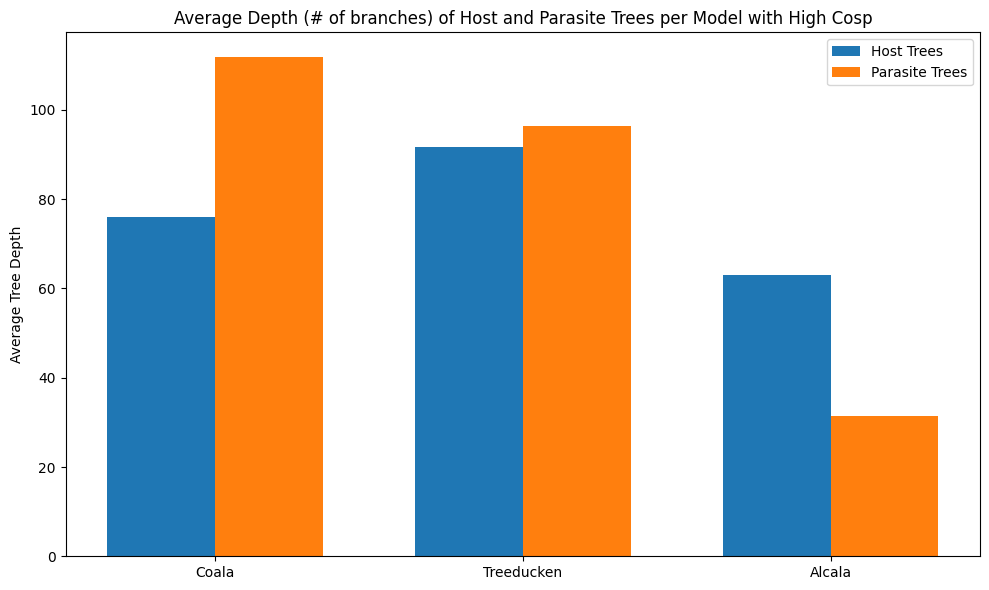

In [33]:
import matplotlib.pyplot as plt

# Compute average depths
host_depths = [
    average_host_tree_depth(datasets_coala_cosp),
    average_host_tree_depth(datasets_treeducken_cosp),
    average_host_tree_depth(datasets_alcala_cosp)
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_coala_cosp),
    average_parasite_tree_depth(datasets_treeducken_cosp),
    average_parasite_tree_depth(datasets_alcala_cosp)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Depth')
plt.title('Average Depth (# of branches) of Host and Parasite Trees per Model with High Cosp')
plt.legend()
plt.tight_layout()
plt.show()

- Compare trees using depth and branches lengths

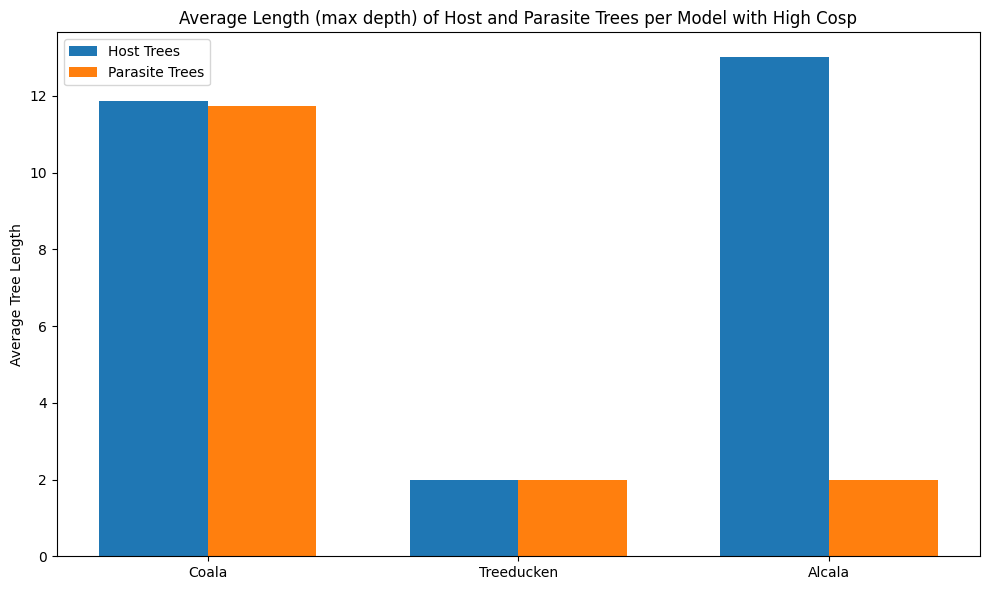

In [34]:
import matplotlib.pyplot as plt

# Compute average lengths
host_lengths = [
    average_host_tree_length(datasets_coala_cosp),
    average_host_tree_length(datasets_treeducken_cosp),
    average_host_tree_length(datasets_alcala_cosp)
]

# Compute average lengths
parasite_lengths = [
    average_parasite_tree_length(datasets_coala_cosp),
    average_parasite_tree_length(datasets_treeducken_cosp),
    average_parasite_tree_length(datasets_alcala_cosp)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_lengths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_lengths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Length')
plt.title('Average Length (max depth) of Host and Parasite Trees per Model with High Cosp')
plt.legend()
plt.tight_layout()
plt.show()

- Compare trees using number of leaves

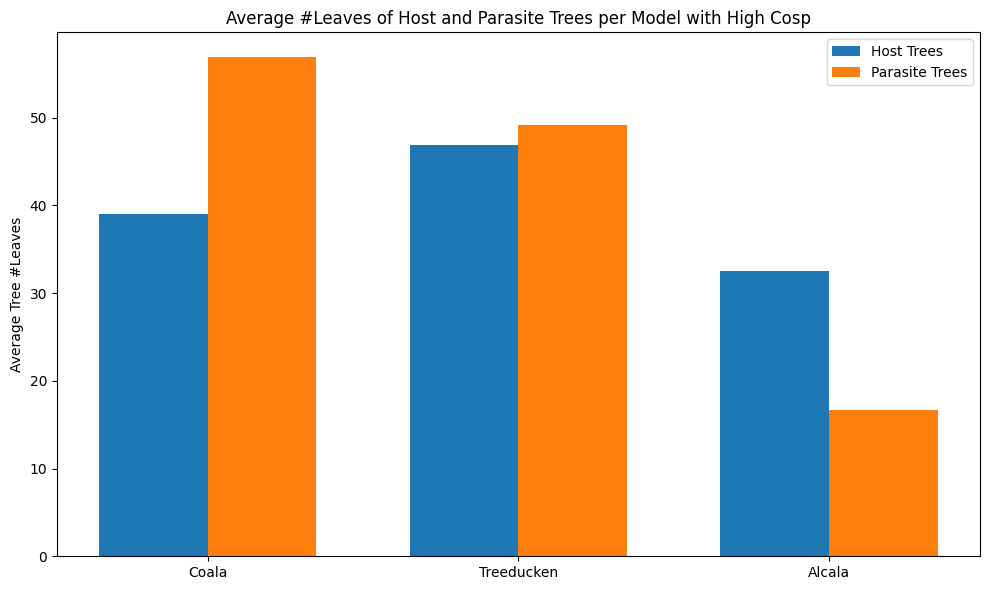

In [88]:
# Compute average depths
host_leaves = [
    average_host_tree_leaves(datasets_coala_cosp),
    average_host_tree_leaves(datasets_treeducken_cosp),
    average_host_tree_leaves(datasets_alcala_cosp)
]

# Compute average depths
parasite_leaves = [
    average_parasite_tree_leaves(datasets_coala_cosp),
    average_parasite_tree_leaves(datasets_treeducken_cosp),
    average_parasite_tree_leaves(datasets_alcala_cosp)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree #Leaves')
plt.title('Average #Leaves of Host and Parasite Trees per Model with High Cosp')
plt.legend()
plt.tight_layout()
plt.show()

- compare tree metrics (cherry, sacking and coless indeces)

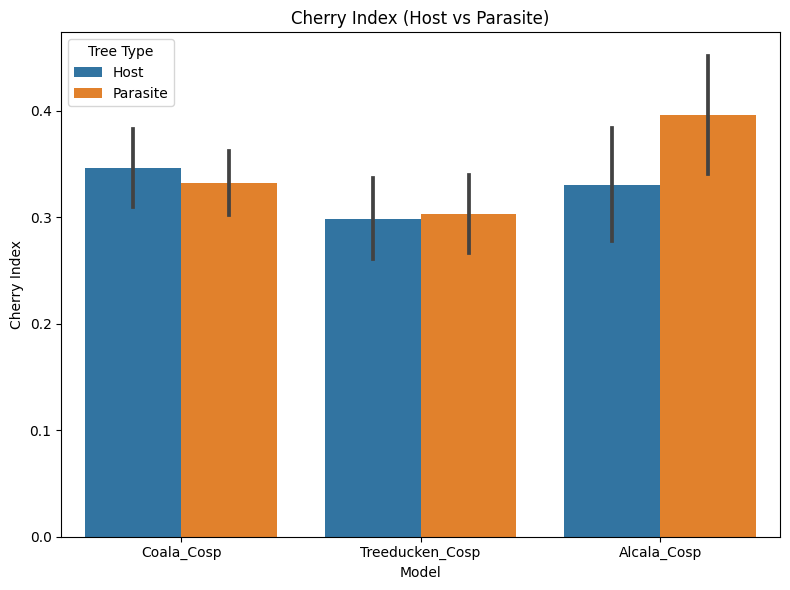

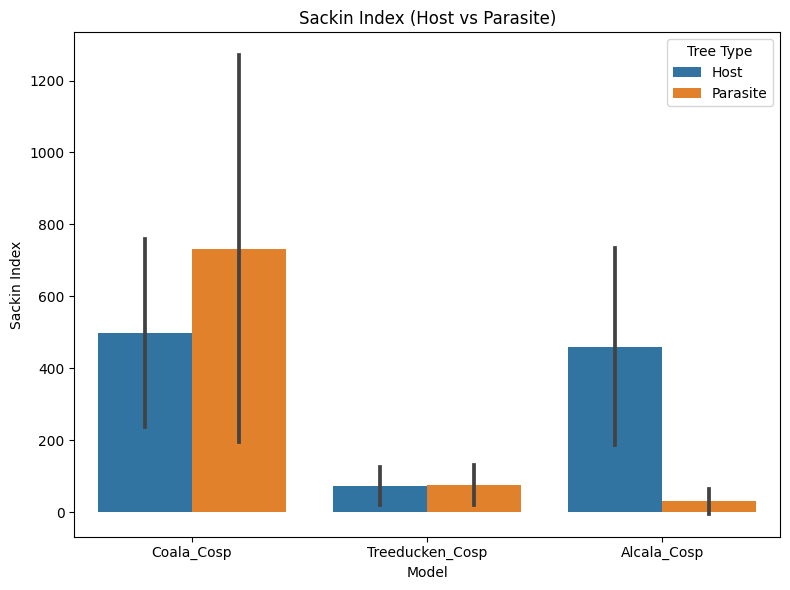

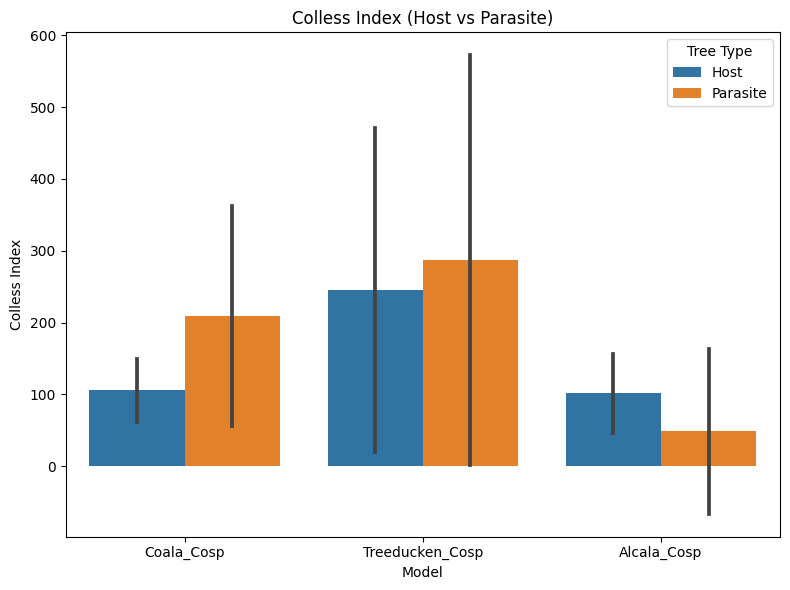

In [106]:
import openpyxl
coala_cosp_metrics = compute_tree_metrics(datasets_coala_cosp, model_name="Coala_Cosp")
treeducken_cosp_metrics = compute_tree_metrics(datasets_treeducken_cosp, model_name="Treeducken_Cosp")
alcala_cosp_metrics = compute_tree_metrics(datasets_alcala_cosp, model_name="Alcala_Cosp")
comparison_metrics_cosp = pd.concat([coala_cosp_metrics, treeducken_cosp_metrics, alcala_cosp_metrics])

comparison_metrics_cosp.to_excel('comparison_metrics_cosp.xlsx', index=False)

metrics_to_plot = [
    'cherry_index_host', 'cherry_index_parasite',
    'sackin_index_host', 'sackin_index_parasite',
    'colless_index_host', 'colless_index_parasite'
]

plot_metric_comparison_paired(comparison_metrics_cosp, 'cherry_index')
plot_metric_comparison_paired(comparison_metrics_cosp, 'sackin_index')
plot_metric_comparison_paired(comparison_metrics_cosp, 'colless_index')

- parafit value

In [125]:
df_coala = run_all_parafit(datasets_coala_cosp, "Coala_Cosp")
df_treeducken = run_all_parafit(datasets_treeducken_cosp, "Treeducken_Cosp")
df_alcala = run_all_parafit(datasets_alcala_cosp, "Alcala_Cosp")

# Combine all results
df_all_parafit = pd.concat([df_coala, df_treeducken, df_alcala], ignore_index=True)

df_all_parafit['is_significant'] = df_all_parafit['parafit_pval'] < 0.05

# Summary stats
summary = df_all_parafit.groupby("model").agg(
    mean_stat=("parafit_stat", "mean"),
    std_stat=("parafit_stat", "std"),
    num_datasets=("parafit_stat", "count"),
    num_significant=("is_significant", "sum")
)

# Add percentage of significant results
summary["pct_significant"] = 100 * summary["num_significant"] / summary["num_datasets"]

# Round for readability
summary = summary.round(2)
summary.to_excel("parafit_summary_cosp.xlsx")
print(summary)

Running ParaFit for Dataset23-1.tgl (Coala_Cosp)
Running ParaFit for Dataset44-1.tgl (Coala_Cosp)
Running ParaFit for Dataset25-1.tgl (Coala_Cosp)
Running ParaFit for Dataset6-1.tgl (Coala_Cosp)
Running ParaFit for Dataset29-1.tgl (Coala_Cosp)
Running ParaFit for Dataset14-1.tgl (Coala_Cosp)
Running ParaFit for Dataset7-1.tgl (Coala_Cosp)
Running ParaFit for Dataset16-1.tgl (Coala_Cosp)
Running ParaFit for Dataset1-1.tgl (Coala_Cosp)
Running ParaFit for Dataset34-1.tgl (Coala_Cosp)
Running ParaFit for Dataset10.tgl (Treeducken_Cosp)
Running ParaFit for Dataset7.tgl (Treeducken_Cosp)
Running ParaFit for Dataset6.tgl (Treeducken_Cosp)
Running ParaFit for Dataset4.tgl (Treeducken_Cosp)
Running ParaFit for Dataset5.tgl (Treeducken_Cosp)
Running ParaFit for Dataset1.tgl (Treeducken_Cosp)
Running ParaFit for Dataset2.tgl (Treeducken_Cosp)
Running ParaFit for Dataset3.tgl (Treeducken_Cosp)
Running ParaFit for Dataset8.tgl (Treeducken_Cosp)
Running ParaFit for Dataset9.tgl (Treeducken_Cosp)
Ru

Errore in `[<-`(`*tmp*`, p, h, value = 1) : subscript fuori limite
Chiamate: compute_parafit
Esecuzione interrotta


Running ParaFit for Dataset_7.tgl (Alcala_Cosp)
Running ParaFit for Dataset_5.tgl (Alcala_Cosp)
[ERROR] R script failed for Dataset_5.tgl: 
Running ParaFit for Dataset_4.tgl (Alcala_Cosp)


Errore in `[<-`(`*tmp*`, p, h, value = 1) : subscript fuori limite
Chiamate: compute_parafit
Esecuzione interrotta


Running ParaFit for Dataset_1.tgl (Alcala_Cosp)
Running ParaFit for Dataset_3.tgl (Alcala_Cosp)
Running ParaFit for Dataset_2.tgl (Alcala_Cosp)
                   mean_stat     std_stat  num_datasets  num_significant  \
model                                                                      
Alcala_Cosp         16912.90     23716.32             2                0   
Coala_Cosp       29487848.43  34774124.20            10               10   
Treeducken_Cosp      2780.22      5884.39            10                9   

                 pct_significant  
model                             
Alcala_Cosp                  0.0  
Coala_Cosp                 100.0  
Treeducken_Cosp             90.0  


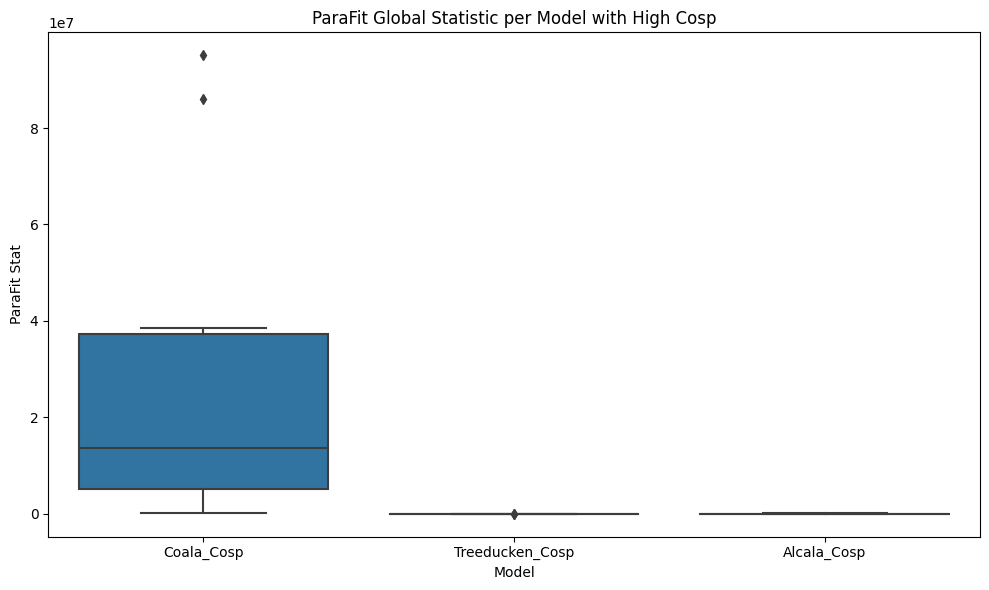

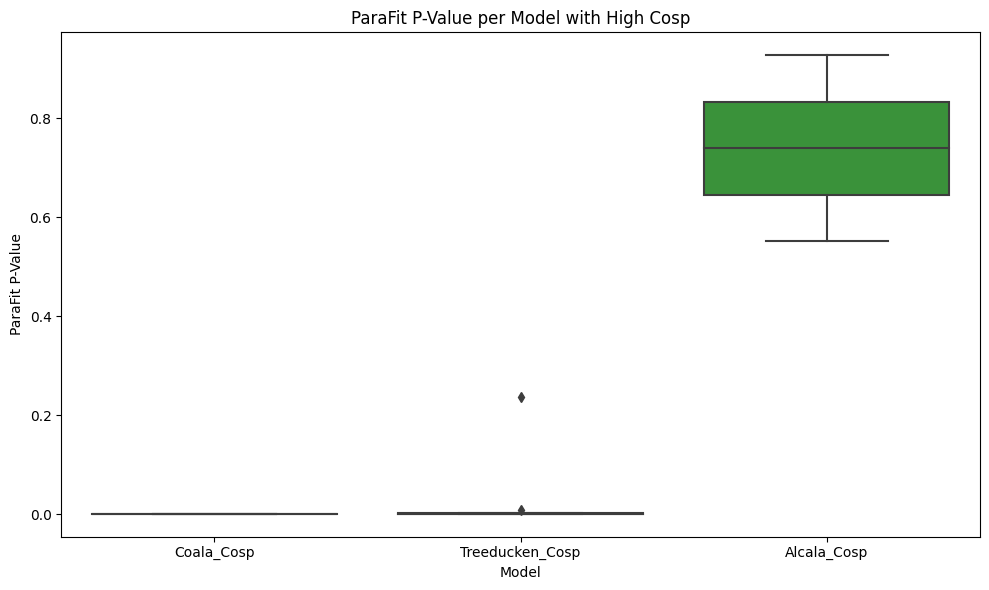

In [126]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit, x="model", y="parafit_stat")
plt.title("ParaFit Global Statistic per Model with High Cosp")
plt.ylabel("ParaFit Stat")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit, x="model", y="parafit_pval")
plt.title("ParaFit P-Value per Model with High Cosp")
plt.ylabel("ParaFit P-Value")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

### High Switch

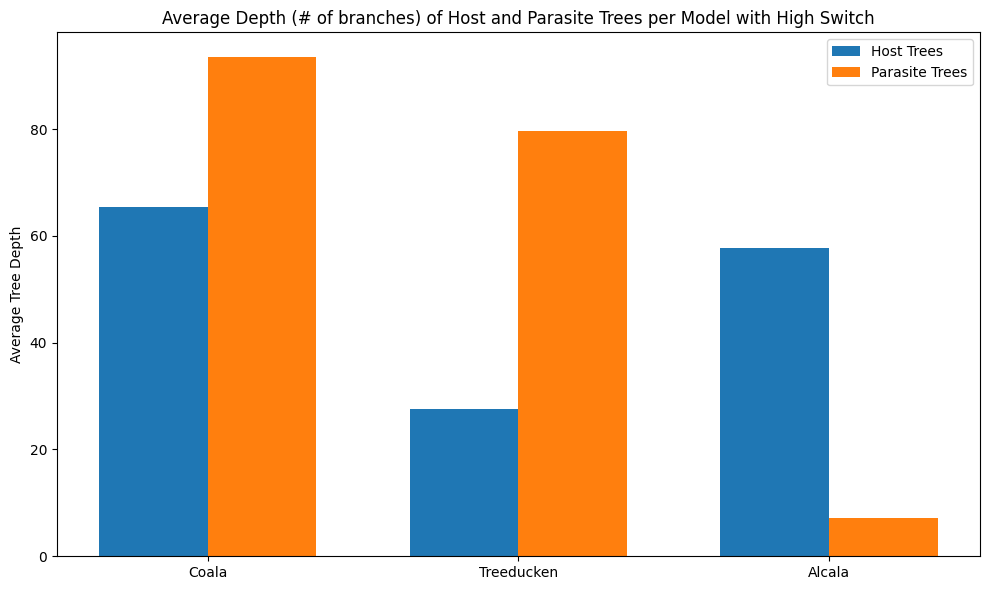

In [36]:
host_depths = [
    average_host_tree_depth(datasets_coala_switch),
    average_host_tree_depth(datasets_treeducken_switch),
    average_host_tree_depth(datasets_alcala_switch)
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_coala_switch),
    average_parasite_tree_depth(datasets_treeducken_switch),
    average_parasite_tree_depth(datasets_alcala_switch)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Depth')
plt.title('Average Depth (# of branches) of Host and Parasite Trees per Model with High Switch')
plt.legend()
plt.tight_layout()
plt.show()

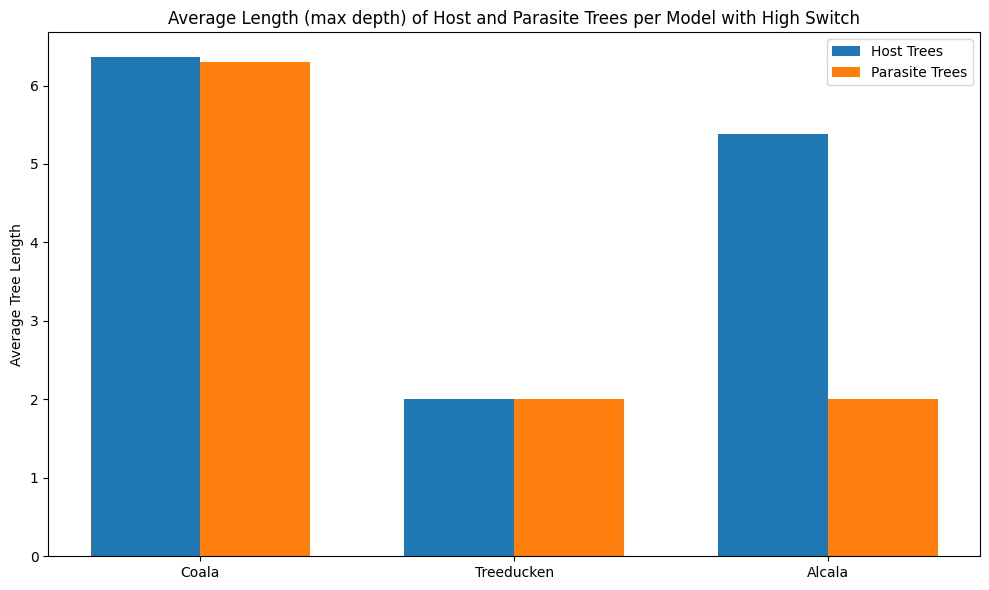

In [37]:
host_lengths = [
    average_host_tree_length(datasets_coala_switch),
    average_host_tree_length(datasets_treeducken_switch),
    average_host_tree_length(datasets_alcala_switch)
]

# Compute average lengths
parasite_lengths = [
    average_parasite_tree_length(datasets_coala_switch),
    average_parasite_tree_length(datasets_treeducken_switch),
    average_parasite_tree_length(datasets_alcala_switch)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_lengths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_lengths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Length')
plt.title('Average Length (max depth) of Host and Parasite Trees per Model with High Switch')
plt.legend()
plt.tight_layout()
plt.show()

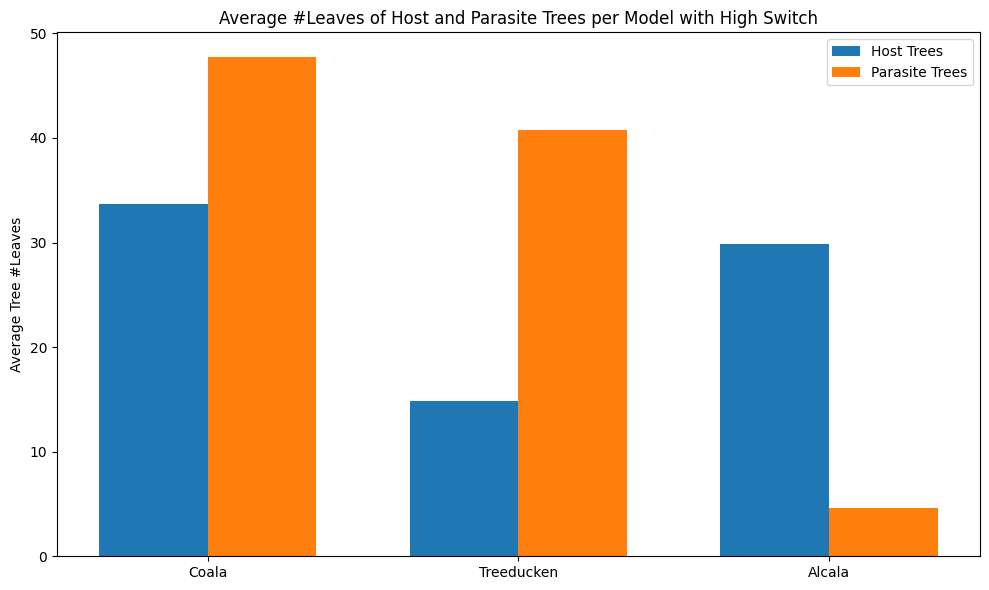

In [38]:
host_leaves = [
    average_host_tree_leaves(datasets_coala_switch),
    average_host_tree_leaves(datasets_treeducken_switch),
    average_host_tree_leaves(datasets_alcala_switch)
]

# Compute average depths
parasite_leaves = [
    average_parasite_tree_leaves(datasets_coala_switch),
    average_parasite_tree_leaves(datasets_treeducken_switch),
    average_parasite_tree_leaves(datasets_alcala_switch)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree #Leaves')
plt.title('Average #Leaves of Host and Parasite Trees per Model with High Switch')
plt.legend()
plt.tight_layout()
plt.show()

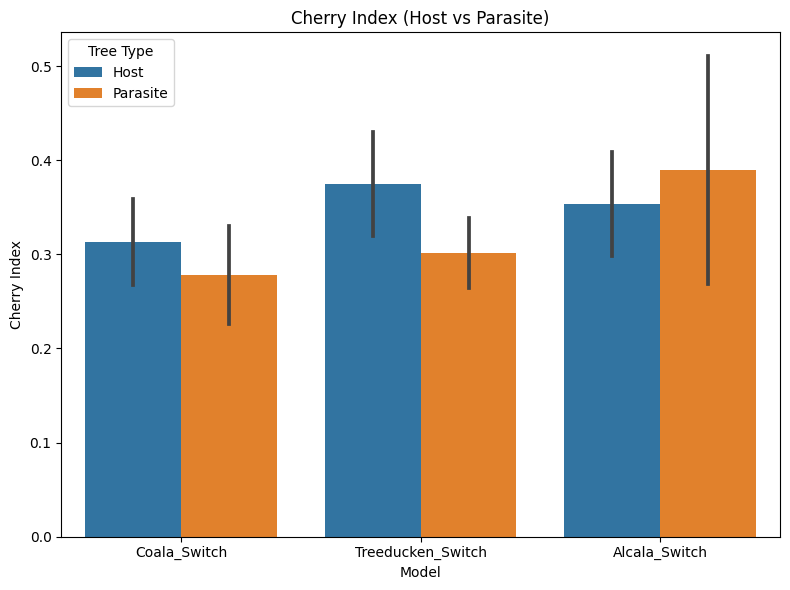

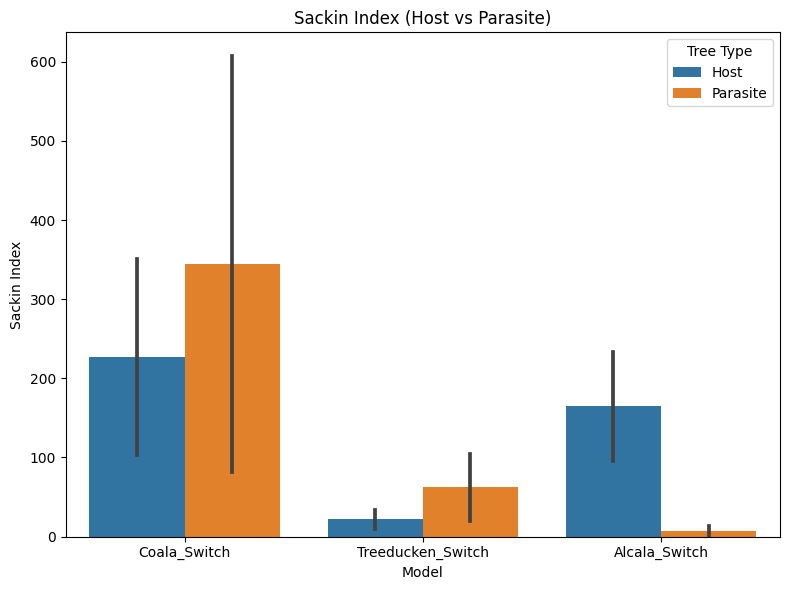

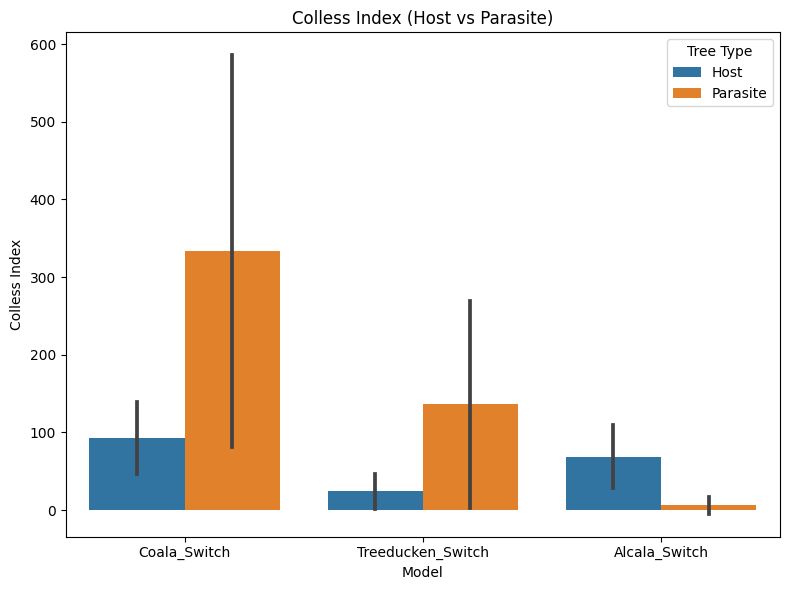

In [107]:
coala_switch_metrics = compute_tree_metrics(datasets_coala_switch, model_name="Coala_Switch")
treeducken_switch_metrics = compute_tree_metrics(datasets_treeducken_switch, model_name="Treeducken_Switch")
alcala_switch_metrics = compute_tree_metrics(datasets_alcala_switch, model_name="Alcala_Switch")
comparison_metrics_switch = pd.concat([coala_switch_metrics, treeducken_switch_metrics, alcala_switch_metrics])

comparison_metrics_switch.to_excel('comparison_metrics_switch.xlsx', index=False)

metrics_to_plot = [
    'cherry_index_host', 'cherry_index_parasite',
    'sackin_index_host', 'sackin_index_parasite',
    'colless_index_host', 'colless_index_parasite'
]


plot_metric_comparison_paired(comparison_metrics_switch, 'cherry_index')
plot_metric_comparison_paired(comparison_metrics_switch, 'sackin_index')
plot_metric_comparison_paired(comparison_metrics_switch, 'colless_index')

- parafit values

In [ ]:
df_coala = run_all_parafit(datasets_coala_switch, "Coala_Switch")
df_treeducken = run_all_parafit(datasets_treeducken_switch, "Treeducken_Switch")
df_alcala = run_all_parafit(datasets_alcala_switch, "Alcala_Switch")

# Combine all results
df_all_parafit_switch = pd.concat([df_coala, df_treeducken, df_alcala], ignore_index=True)

df_all_parafit_switch['is_significant'] = df_all_parafit_switch['parafit_pval'] < 0.05

# Summary stats
summary_switch = df_all_parafit_switch.groupby("model").agg(
    mean_stat=("parafit_stat", "mean"),
    std_stat=("parafit_stat", "std"),
    num_datasets=("parafit_stat", "count"),
    num_significant=("is_significant", "sum")
)

# Add percentage of significant results
summary_switch["pct_significant"] = 100 * summary_switch["num_significant"] / summary_switch["num_datasets"]

# Round for readability
summary_switch = summary_switch.round(2)
summary_switch.to_excel("parafit_summary_switch.xlsx")

print(summary_switch)

Running ParaFit for Dataset21-1.tgl (Coala_Switch)
Running ParaFit for Dataset79-1.tgl (Coala_Switch)
Running ParaFit for Dataset78-1.tgl (Coala_Switch)
Running ParaFit for Dataset49-1.tgl (Coala_Switch)
Running ParaFit for Dataset31-1.tgl (Coala_Switch)
Running ParaFit for Dataset91-1.tgl (Coala_Switch)
Running ParaFit for Dataset16-1.tgl (Coala_Switch)
Running ParaFit for Dataset10.tgl (Treeducken_Switch)
Running ParaFit for Dataset7.tgl (Treeducken_Switch)
Running ParaFit for Dataset6.tgl (Treeducken_Switch)
Running ParaFit for Dataset4.tgl (Treeducken_Switch)
Running ParaFit for Dataset5.tgl (Treeducken_Switch)
Running ParaFit for Dataset1.tgl (Treeducken_Switch)
Running ParaFit for Dataset2.tgl (Treeducken_Switch)
Running ParaFit for Dataset3.tgl (Treeducken_Switch)
Running ParaFit for Dataset8.tgl (Treeducken_Switch)
Running ParaFit for Dataset9.tgl (Treeducken_Switch)
Running ParaFit for Dataset_9.tgl (Alcala_Switch)
Running ParaFit for Dataset_8.tgl (Alcala_Switch)
Running Para

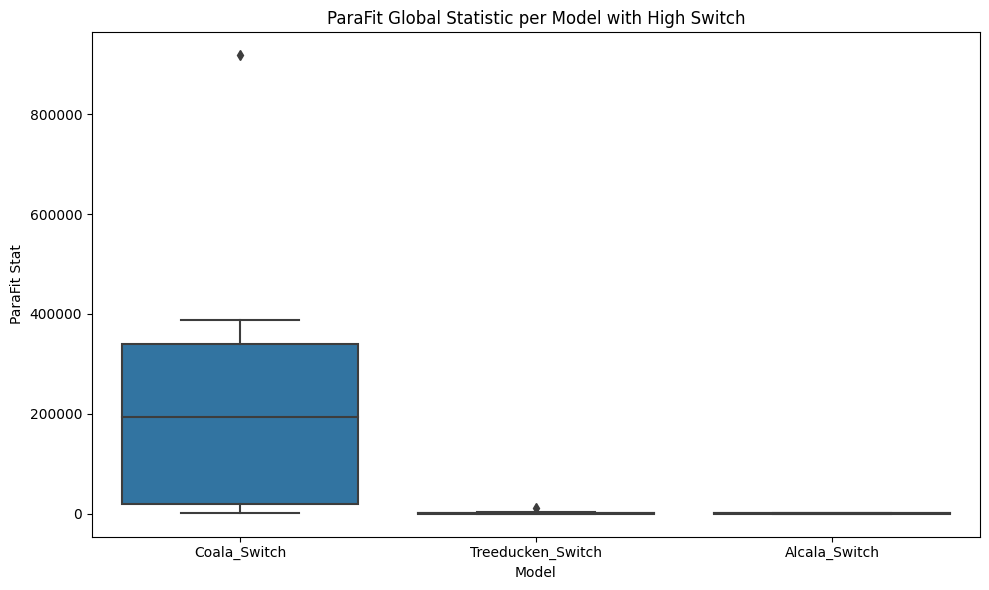

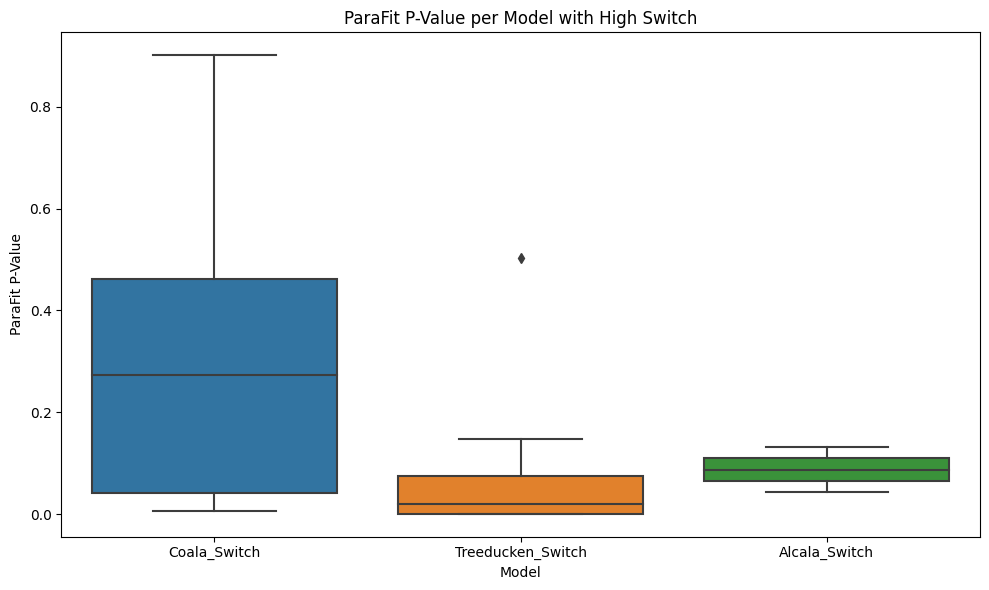

In [128]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit_switch, x="model", y="parafit_stat")
plt.title("ParaFit Global Statistic per Model with High Switch")
plt.ylabel("ParaFit Stat")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit_switch, x="model", y="parafit_pval")
plt.title("ParaFit P-Value per Model with High Switch")
plt.ylabel("ParaFit P-Value")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

### Medium Values

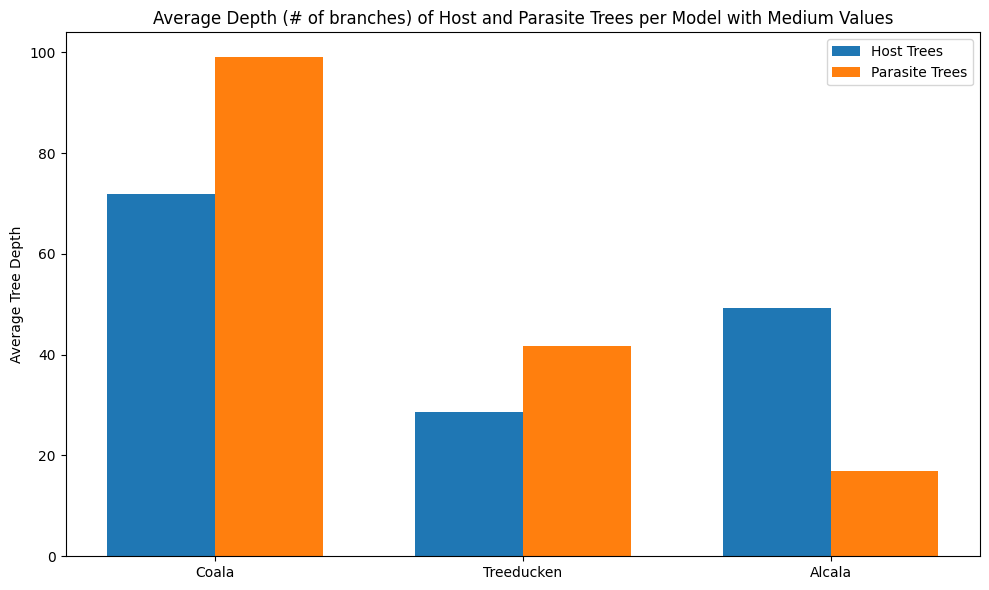

In [39]:
host_depths = [
    average_host_tree_depth(datasets_coala_med),
    average_host_tree_depth(datasets_treeducken_medium),
    average_host_tree_depth(datasets_alcala_medium)
]

# Compute average depths
parasite_depths = [
    average_parasite_tree_depth(datasets_coala_med),
    average_parasite_tree_depth(datasets_treeducken_medium),
    average_parasite_tree_depth(datasets_alcala_medium)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_depths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_depths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Depth')
plt.title('Average Depth (# of branches) of Host and Parasite Trees per Model with Medium Values')
plt.legend()
plt.tight_layout()
plt.show()

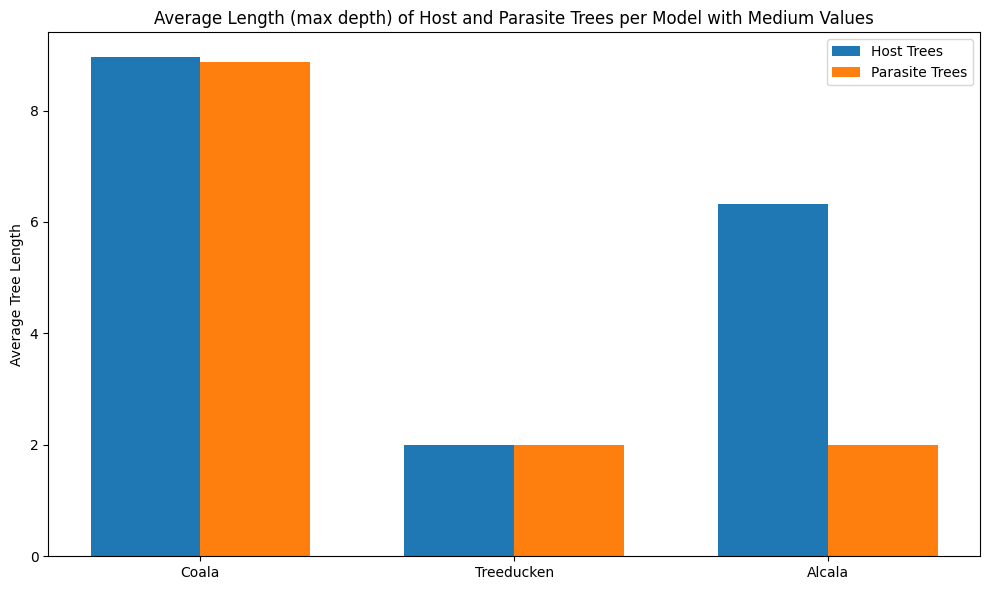

In [40]:
host_lengths = [
    average_host_tree_length(datasets_coala_med),
    average_host_tree_length(datasets_treeducken_medium),
    average_host_tree_length(datasets_alcala_medium)
]

# Compute average lengths
parasite_lengths = [
    average_parasite_tree_length(datasets_coala_med),
    average_parasite_tree_length(datasets_treeducken_medium),
    average_parasite_tree_length(datasets_alcala_medium)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_lengths, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_lengths, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree Length')
plt.title('Average Length (max depth) of Host and Parasite Trees per Model with Medium Values')
plt.legend()
plt.tight_layout()
plt.show()

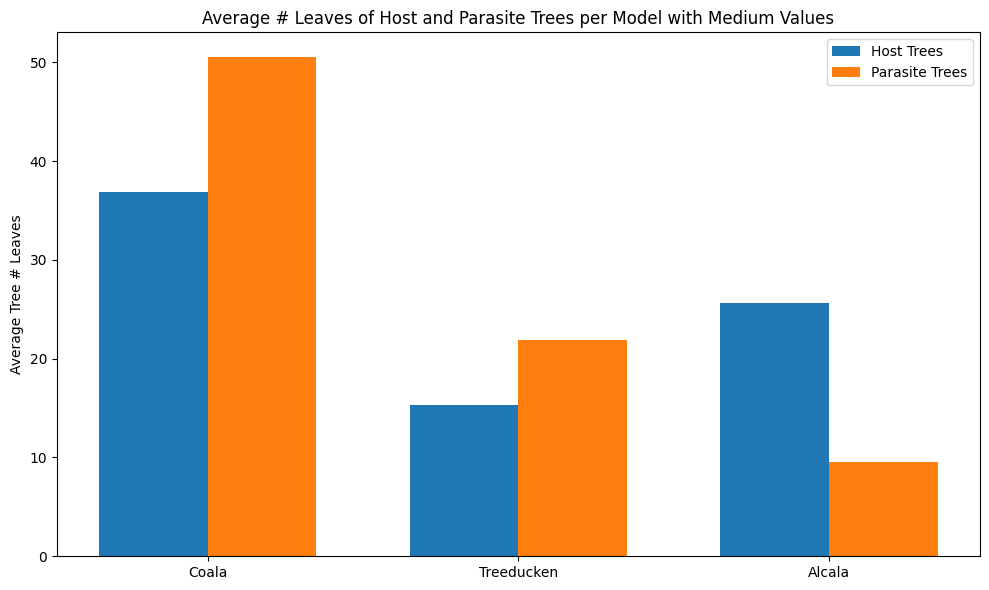

In [41]:
host_leaves = [
    average_host_tree_leaves(datasets_coala_med),
    average_host_tree_leaves(datasets_treeducken_medium),
    average_host_tree_leaves(datasets_alcala_medium)
]

# Compute average lengths
parasite_leaves = [
    average_parasite_tree_leaves(datasets_coala_med),
    average_parasite_tree_leaves(datasets_treeducken_medium),
    average_parasite_tree_leaves(datasets_alcala_medium)
]

# Plotting
labels = ['Coala', 'Treeducken', 'Alcala']
x = range(len(labels))

bar_width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - bar_width/2 for i in x], host_leaves, width=bar_width, label='Host Trees')
plt.bar([i + bar_width/2 for i in x], parasite_leaves, width=bar_width, label='Parasite Trees')
plt.xticks(ticks=x, labels=labels)
plt.ylabel('Average Tree # Leaves')
plt.title('Average # Leaves of Host and Parasite Trees per Model with Medium Values')
plt.legend()
plt.tight_layout()
plt.show()

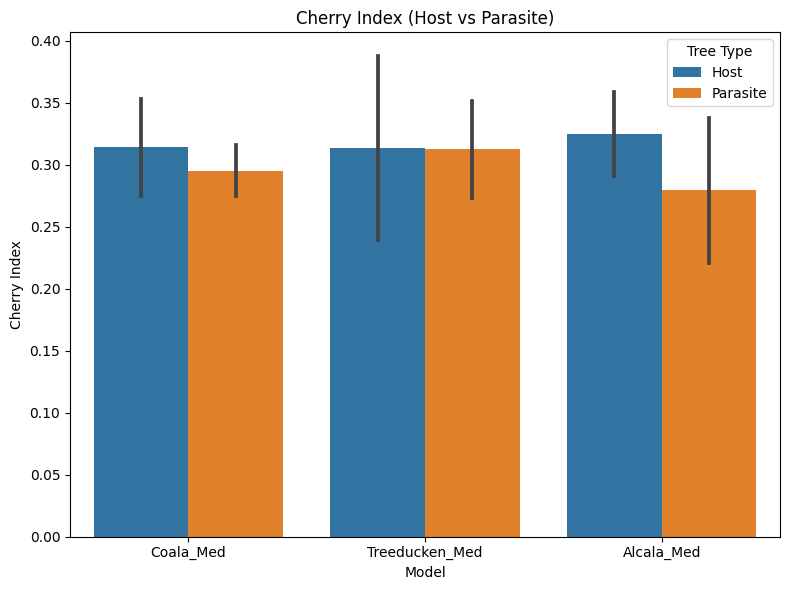

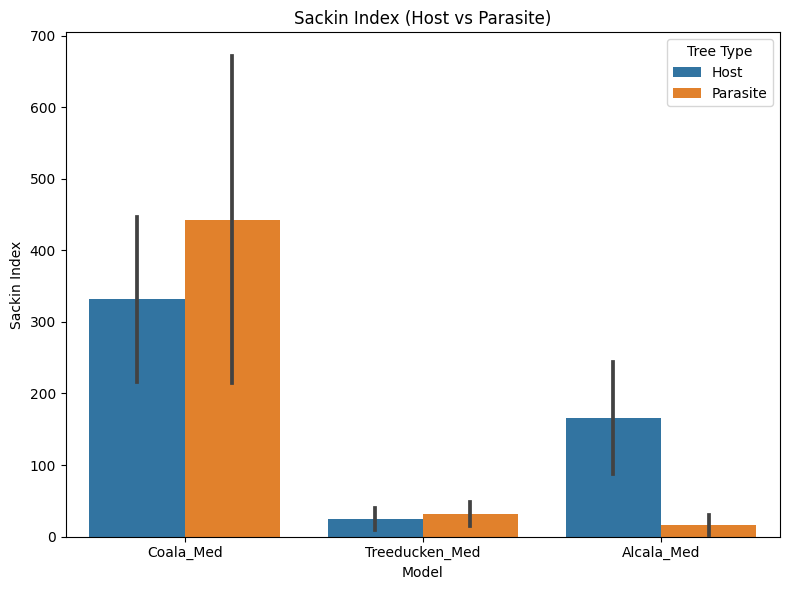

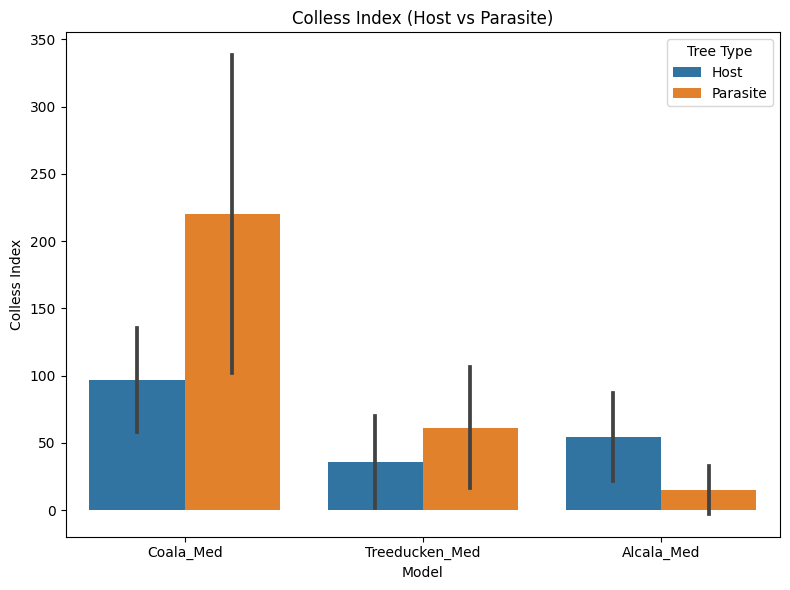

In [108]:
coala_medium_metrics = compute_tree_metrics(datasets_coala_med, model_name="Coala_Med")
treeducken_medium_metrics = compute_tree_metrics(datasets_treeducken_medium, model_name="Treeducken_Med")
alcala_medium_metrics = compute_tree_metrics(datasets_alcala_medium, model_name="Alcala_Med")
comparison_metrics_medium = pd.concat([coala_medium_metrics, treeducken_medium_metrics, alcala_medium_metrics])

comparison_metrics_medium.to_excel('comparison_metrics_medium.xlsx', index=False)

metrics_to_plot = [
    'cherry_index_host', 'cherry_index_parasite',
    'sackin_index_host', 'sackin_index_parasite',
    'colless_index_host', 'colless_index_parasite'
]



plot_metric_comparison_paired(comparison_metrics_medium, 'cherry_index')
plot_metric_comparison_paired(comparison_metrics_medium, 'sackin_index')
plot_metric_comparison_paired(comparison_metrics_medium, 'colless_index')

- parafit value 

In [130]:
df_coala = run_all_parafit(datasets_coala_med, "Coala_Medium")
df_treeducken = run_all_parafit(datasets_treeducken_medium, "Treeducken_Medium")
df_alcala = run_all_parafit(datasets_alcala_medium, "Alcala_Medium")

# Combine all results
df_all_parafit_medium = pd.concat([df_coala, df_treeducken, df_alcala], ignore_index=True)

df_all_parafit_medium['is_significant'] = df_all_parafit_medium['parafit_pval'] < 0.05

# Summary stats
summary_medium = df_all_parafit_medium.groupby("model").agg(
    mean_stat=("parafit_stat", "mean"),
    std_stat=("parafit_stat", "std"),
    num_datasets=("parafit_stat", "count"),
    num_significant=("is_significant", "sum")
)

# Add percentage of significant results
summary_medium["pct_significant"] = 100 * summary_medium["num_significant"] / summary_medium["num_datasets"]

# Round for readability
summary_medium = summary_medium.round(2)
summary_medium.to_excel("parafit_summary_medium.xlsx")

print(summary_medium)

Running ParaFit for Dataset27-1.tgl (Coala_Medium)
Running ParaFit for Dataset22-1.tgl (Coala_Medium)
Running ParaFit for Dataset17-1.tgl (Coala_Medium)
Running ParaFit for Dataset15-1.tgl (Coala_Medium)
Running ParaFit for Dataset11-1.tgl (Coala_Medium)
Running ParaFit for Dataset5-1.tgl (Coala_Medium)
Running ParaFit for Dataset12-1.tgl (Coala_Medium)
Running ParaFit for Dataset36-1.tgl (Coala_Medium)
Running ParaFit for Dataset3-1.tgl (Coala_Medium)
Running ParaFit for Dataset10-1.tgl (Coala_Medium)
Running ParaFit for Dataset10.tgl (Treeducken_Medium)
Running ParaFit for Dataset7.tgl (Treeducken_Medium)
Running ParaFit for Dataset6.tgl (Treeducken_Medium)
Running ParaFit for Dataset4.tgl (Treeducken_Medium)
Running ParaFit for Dataset5.tgl (Treeducken_Medium)
Running ParaFit for Dataset1.tgl (Treeducken_Medium)
Running ParaFit for Dataset2.tgl (Treeducken_Medium)
Running ParaFit for Dataset3.tgl (Treeducken_Medium)
Running ParaFit for Dataset8.tgl (Treeducken_Medium)
Running ParaFi

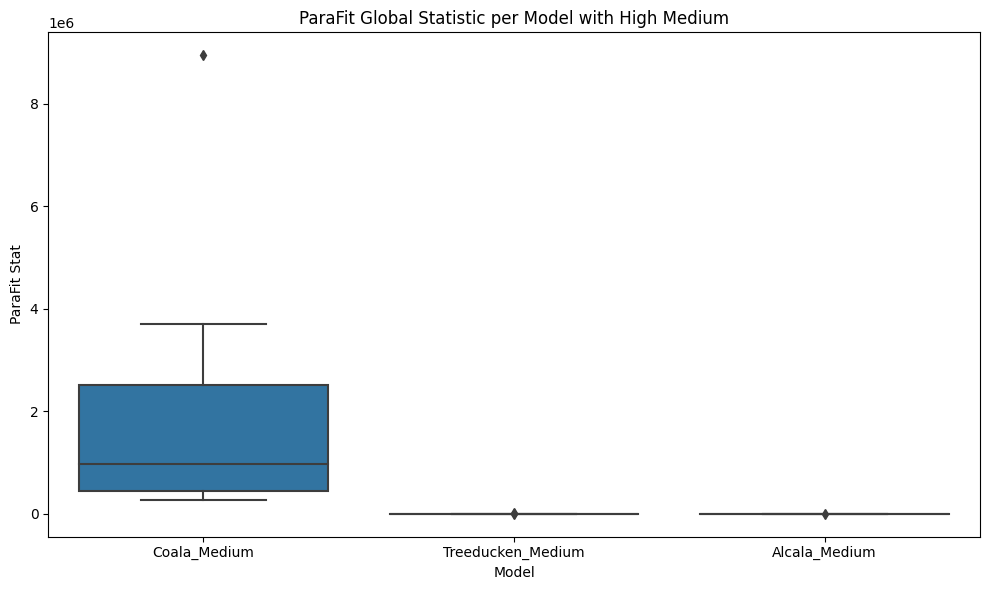

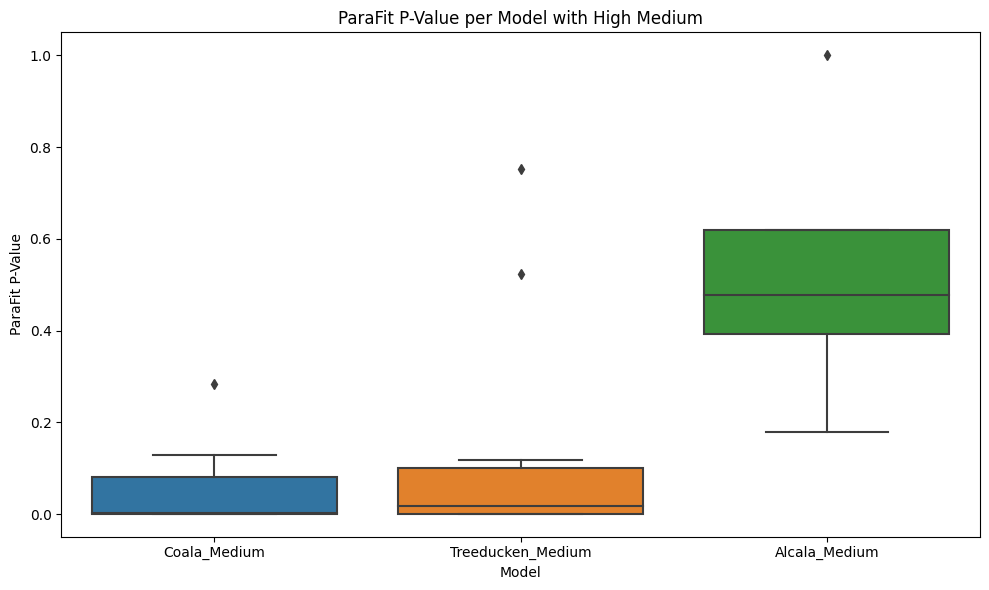

In [131]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit_medium, x="model", y="parafit_stat")
plt.title("ParaFit Global Statistic per Model with High Medium")
plt.ylabel("ParaFit Stat")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_parafit_medium, x="model", y="parafit_pval")
plt.title("ParaFit P-Value per Model with High Medium")
plt.ylabel("ParaFit P-Value")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

## Compare Networks

In [44]:
# functions to get bipartite graphs
import networkx as nx
import matplotlib.pyplot as plt

def build_bipartite_graph(dataset, show_plot=True, save_path=None):
    associations = dataset['associations']
    host_nodes = {h for _, h in associations}
    parasite_nodes = {p for p, _ in associations}

    G = nx.Graph()
    
    # Add nodes with bipartite attribute
    G.add_nodes_from(host_nodes, bipartite='host')
    G.add_nodes_from(parasite_nodes, bipartite='parasite')
    
    # Add edges
    G.add_edges_from(associations)

    if show_plot or save_path:
        plt.figure(figsize=(10, 6))
        pos = {}
        pos.update((n, (1, i)) for i, n in enumerate(sorted(host_nodes)))  # Hosts at y=1
        pos.update((n, (2, i)) for i, n in enumerate(sorted(parasite_nodes)))  # Parasites at y=2

        nx.draw(G, pos=pos, with_labels=True, node_color=["skyblue" if n in host_nodes else "salmon" for n in G.nodes()], edge_color="gray")
        plt.title(f"Bipartite Graph - {dataset['filename']}")
        plt.axis("off")
        
        if save_path:
            plt.savefig(save_path, bbox_inches="tight")
        if show_plot:
            plt.show()
        else:
            plt.close()

    return G

def generate_all_bipartite_graphs(datasets, show_plots=False, save_dir=None):

    import os

    graphs = {}
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    for dataset in datasets:
        filename = dataset['filename']
        save_path = f"{save_dir}/{filename.replace('.tgl', '')}_bipartite.png" if save_dir else None
        G = build_bipartite_graph(dataset, show_plot=show_plots, save_path=save_path)
        graphs[filename] = G

    return graphs

### High Cospeciation

In [53]:
treeducken_graphs_cosp = generate_all_bipartite_graphs(datasets_treeducken_cosp, show_plots=False, save_dir="treeducken/treeducken_cosp_bipartite_graphs")
coala_graphs_cosp = generate_all_bipartite_graphs(datasets_coala_cosp, show_plots=False, save_dir="coala/coala_cosp_bipartite_graphs")
alcala_graphs_cosp = generate_all_bipartite_graphs(datasets_alcala_cosp, show_plots=False, save_dir="alcala/alcala_cosp_bipartite_graphs")

### High Switch

In [54]:
treeducken_graphs_switch = generate_all_bipartite_graphs(datasets_treeducken_switch, show_plots=False, save_dir="treeducken/treeducken_switch_bipartite_graphs")
coala_graphs_switch = generate_all_bipartite_graphs(datasets_coala_switch, show_plots=False, save_dir="coala/coala_switch_bipartite_graphs")
alcala_graphs_switch = generate_all_bipartite_graphs(datasets_alcala_switch, show_plots=False, save_dir="alcala/alcala_switch_bipartite_graphs")

### Medium values

In [55]:
treeducken_graphs_medium = generate_all_bipartite_graphs(datasets_treeducken_medium, show_plots=False, save_dir="treeducken/treeducken_medium_bipartite_graphs")
coala_graphs_medium = generate_all_bipartite_graphs(datasets_coala_med, show_plots=False, save_dir="coala/coala_medium_bipartite_graphs")
alcala_graphs_medium = generate_all_bipartite_graphs(datasets_alcala_medium, show_plots=False, save_dir="alcala/alcala_medium_bipartite_graphs")